# DATA 2010 Project — Olympics (1896–2024)
**Notebook flow :**
1) Load data
2) Data types + variable types + granularity
3) Dataset inspection
4) Missing values + outliers 
5) Comprehensive facts
6) Cleaning
7) Feature engineering
8) Interesting facts + quick plots




## 1) Loading the data

In [57]:
### Imports + folders
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("figures", exist_ok=True)
os.makedirs("outputs", exist_ok=True)


In [58]:
### Load the CSV (update path)
path = r"C:\Users\princ\OneDrive\Documents\OneDrive\Desktop\olympics_1896_2024.csv"

df_raw = pd.read_csv(path, low_memory=False)
print("Loaded shape (rows, cols):", df_raw.shape)

df = df_raw.copy()
df.head()


Loaded shape (rows, cols): (290697, 8)


,sex,age,team,year,season,sports,event,medal
0,M,72,Great Britain,1948,Summer,Art Competitions,"Art Competitions Mixed Sculpturing, Medals And...",NaN
1,M,72,Latvia,1936,Summer,Art Competitions,"Art Competitions Mixed Painting, Paintings",NaN
2,M,72,Austria,1936,Summer,Equestrianism,"Equestrianism Men's Dressage, Individual",NaN
3,M,72,Austria,1936,Summer,Equestrianism,"Equestrianism Men's Dressage, Team",NaN
4,M,72,Netherlands,1928,Summer,Art Competitions,"Art Competitions Mixed Painting, Paintings",NaN


## 2) Data types, variable types, and granularity

In [59]:
### 2A) Pandas data types + missing counts
dtype_table = pd.DataFrame({
    "column": df.columns,
    "pandas_dtype": [df[c].dtype for c in df.columns],
    "missing_count": [df[c].isna().sum() for c in df.columns]
}).sort_values("column")

dtype_table


,column,pandas_dtype,missing_count
1,age,int64,0
6,event,object,0
7,medal,object,247941
4,season,object,0
0,sex,object,0
5,sports,object,0
2,team,object,0
3,year,int64,0


In [60]:
### 2B) Variable type classification (Quantitative vs Qualitative Nominal/Ordinal)

def classify_variable(col_name: str):
    col = col_name.lower()

    if col in ["age", "age_imputed", "year", "medal_points"]:
        return "Quantitative"
    if col in ["decade", "age_group"]:
        return "Qualitative (Ordinal)"
    if col in ["name", "sex", "team", "noc", "season", "city", "sports", "event", "medal", "team_clean", "won_medal"]:
        return "Qualitative (Nominal)"

    if pd.api.types.is_numeric_dtype(df[col_name]):
        return "Quantitative"
    return "Qualitative (Nominal)"

var_type_table = pd.DataFrame({
    "column": df.columns,
    "pandas_dtype": [df[c].dtype for c in df.columns],
    "variable_type": [classify_variable(c) for c in df.columns]
}).sort_values(["variable_type", "column"])

var_type_table


,column,pandas_dtype,variable_type
6,event,object,Qualitative (Nominal)
7,medal,object,Qualitative (Nominal)
4,season,object,Qualitative (Nominal)
0,sex,object,Qualitative (Nominal)
5,sports,object,Qualitative (Nominal)
2,team,object,Qualitative (Nominal)
1,age,int64,Quantitative
3,year,int64,Quantitative


In [61]:
### 2C) Granularity (what one row represents)
### Proxy check: uniqueness of (name, year, event)

granularity_key = ["name", "year", "event"]
missing_g = [c for c in granularity_key if c not in df.columns]

if missing_g:
    print("Cannot verify granularity because missing:", missing_g)
else:
    total_rows = df.shape[0]
    unique_rows = df.drop_duplicates(granularity_key).shape[0]
    dup = total_rows - unique_rows

    print("Total rows:", total_rows)
    print("Unique rows by (name, year, event):", unique_rows)
    print("Duplicates under this key:", dup)

    print("\nInterpretation:")
    print("- Intended: one athlete entry in one event in one year.")
    print("- Duplicates can occur due to team events or repeated records.")


Cannot verify granularity because missing: ['name']


## 3) Dataset inspection

In [62]:
### Shape + columns
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Columns list:", df.columns.tolist())


Rows: 290697
Columns: 8
Columns list: ['sex', 'age', 'team', 'year', 'season', 'sports', 'event', 'medal']


In [63]:
### Sample rows
df.sample(5, random_state=42)


,sex,age,team,year,season,sports,event,medal
66319,M,29,Australia,1992,Summer,Water Polo,Water Polo Men's Water Polo,NaN
20453,M,35,South Africa,1960,Summer,Athletics,Athletics Men's 20 kilometres Walk,NaN
122438,M,26,Switzerland,1960,Winter,Cross Country Skiing,Cross Country Skiing Men's 15 kilometres,NaN
248248,M,20,Nigeria,1988,Summer,Boxing,Boxing Men's Bantamweight,NaN
224855,M,21,South Korea,2002,Winter,Speed Skating,"Speed Skating Men's 1,000 metres",NaN


In [64]:
### Numeric summary (if any numeric columns exist)
df.describe(include=[np.number]).T


,count,mean,std,min,25%,50%,75%,max
age,290697.0,25.684207,6.282759,10.0,22.0,25.0,29.0,72.0
year,290697.0,1984.278324,29.894844,1896.0,1968.0,1992.0,2008.0,2024.0


In [65]:
### Year range + unique years (year is already numeric in this dataset)
if "year" in df.columns:
    print("Year range:", df["year"].min(), "to", df["year"].max())
    print("Unique years:", df["year"].nunique())


Year range: 1896 to 2024
Unique years: 38


## 4) Missing values and outliers (only handle if needed)

In [66]:
### Missing values by column (top 15)
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_counts.head(15)


medal     247941
sex            0
age            0
team           0
year           0
season         0
sports         0
event          0
dtype: int64

In [67]:
### Total missing values
total_missing = int(df.isna().sum().sum())
print("Total missing values:", total_missing)

if total_missing == 0:
    print("No missing values found. Skipping imputation.")


Total missing values: 247941


In [68]:
### Outlier check for age (flag only; do not delete)
if "age" in df.columns:
    print("Age range (raw):", df["age"].min(), "to", df["age"].max())
    suspicious = df["age"].notna() & ((df["age"] < 10) | (df["age"] > 75))
    print("Suspicious age rows:", int(suspicious.sum()))
else:
    print("No age column found.")


Age range (raw): 10 to 72
Suspicious age rows: 0


## 5) Comprehensive facts and inspections

In [69]:
### Quick facts (sex, medal, unique teams/sports/events, editions)
facts = {}

if "sex" in df.columns:
    facts["sex_counts"] = df["sex"].value_counts(dropna=False).to_dict()

if "medal" in df.columns:
    facts["medal_counts_top10"] = df["medal"].value_counts(dropna=False).head(10).to_dict()

for col in ["team", "sports", "event"]:
    if col in df.columns:
        facts[f"unique_{col}"] = int(df[col].nunique())

ed_cols = ["year", "season", "city"]
if all(c in df.columns for c in ed_cols):
    facts["editions_year_season_city"] = int(df.drop_duplicates(ed_cols).shape[0])

# Empty-string medal check
if "medal" in df.columns:
    facts["empty_string_medal_rows"] = int((df["medal"].astype(str).str.strip() == "").sum())

facts


{'sex_counts': {'M': 202596, 'F': 88101},
 'medal_counts_top10': {nan: 247941,
  'Gold': 14407,
  'Bronze': 14333,
  'Silver': 14016},
 'unique_team': 1151,
 'unique_sports': 92,
 'unique_event': 1534,
 'empty_string_medal_rows': 0}

## 6) Data cleaning (apply only if needed)

In [70]:
### 6A) Standardize sex values to M/F (safe if already M/F)
if "sex" in df.columns:
    before = df["sex"].value_counts(dropna=False)
    df["sex"] = df["sex"].astype(str).str.strip()
    df["sex"] = df["sex"].replace({
        "Male": "M", "male": "M", "m": "M",
        "Female": "F", "female": "F", "f": "F"
    })
    after = df["sex"].value_counts(dropna=False)

    print("Sex values before:\n", before.head(10))
    print("\nSex values after:\n", after.head(10))


Sex values before:
 sex
M    202596
F     88101
Name: count, dtype: int64

Sex values after:
 sex
M    202596
F     88101
Name: count, dtype: int64


In [71]:
### 6B) Remove exact duplicates (before/after)
dup_before = int(df.duplicated().sum())
df = df.drop_duplicates().copy()
dup_after = int(df.duplicated().sum())

print("Duplicate rows before:", dup_before)
print("Duplicate rows after: ", dup_after)
print("Shape after dropping duplicates:", df.shape)


Duplicate rows before: 35568
Duplicate rows after:  0
Shape after dropping duplicates: (255129, 8)


In [72]:
### 6C) Impute age ONLY if missing ages exist
if "age" in df.columns:
    missing_age_before = int(df["age"].isna().sum())
    print("Missing age before:", missing_age_before)

    if missing_age_before == 0:
        df["age_imputed"] = df["age"]
        print("No missing age. age_imputed equals age.")
    else:
        overall_median = df["age"].median()
        df["age_imputed"] = df["age"]
        group_median = df.groupby(["sex", "sports"])["age"].transform("median")
        df["age_imputed"] = df["age_imputed"].fillna(group_median)
        df["age_imputed"] = df["age_imputed"].fillna(overall_median)

        missing_age_after = int(df["age_imputed"].isna().sum())
        print("Missing age after (age_imputed):", missing_age_after)
else:
    print("No age column found.")


Missing age before: 0
No missing age. age_imputed equals age.


In [73]:
### 6D) Flag suspicious ages (outliers), do not remove
if "age_imputed" in df.columns:
    df["age_flag_suspicious"] = (df["age_imputed"] < 10) | (df["age_imputed"] > 75)
    print("Suspicious age rows:", int(df["age_flag_suspicious"].sum()))


Suspicious age rows: 0


## 7) Feature engineering

In [74]:
### 7A) Decade
df["decade"] = (df["year"] // 10) * 10

### 7B) Won medal flag
df["won_medal"] = df["medal"].isin(["Gold", "Silver", "Bronze"]).astype(int)

### 7C) Medal points
points_map = {"Gold": 3, "Silver": 2, "Bronze": 1}
df["medal_points"] = df["medal"].map(points_map).fillna(0).astype(int)

df[["year","decade","medal","won_medal","medal_points"]].head()


,year,decade,medal,won_medal,medal_points
0,1948,1940,NaN,0,0
1,1936,1930,NaN,0,0
2,1936,1930,NaN,0,0
3,1936,1930,NaN,0,0
4,1928,1920,NaN,0,0


In [75]:
### 7D) Missing year info + gaps between min/max
missing_year_rows = int(df["year"].isna().sum())
print("Missing year rows:", missing_year_rows)

year_min, year_max = int(df["year"].min()), int(df["year"].max())
years_present = set(df["year"].dropna().unique())
missing_years_list = [y for y in range(year_min, year_max + 1) if y not in years_present]

print("Year min:", year_min, "| Year max:", year_max)
print("Missing years between min/max:", len(missing_years_list))
missing_years_list[:30]


Missing year rows: 0
Year min: 1896 | Year max: 2024
Missing years between min/max: 91


[1897,
 1898,
 1899,
 1901,
 1902,
 1903,
 1905,
 1907,
 1909,
 1910,
 1911,
 1913,
 1914,
 1915,
 1916,
 1917,
 1918,
 1919,
 1921,
 1922,
 1923,
 1925,
 1926,
 1927,
 1929,
 1930,
 1931,
 1933,
 1934,
 1935]

## 8) Interesting facts + key plots

In [76]:
### 8A) Sex proportions (table)
sex_counts = df["sex"].value_counts(dropna=False)
sex_prop = (sex_counts / sex_counts.sum() * 100).round(2)
pd.DataFrame({"count": sex_counts, "percent": sex_prop})


,count,percent
sex,,
M,177018,69.38
F,78111,30.62


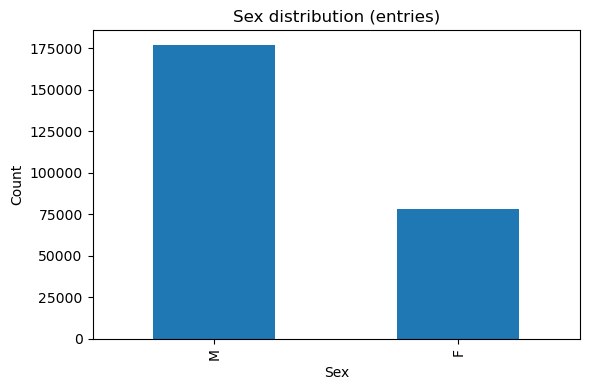

In [77]:
### Plot: Sex distribution
plt.figure(figsize=(6,4))
sex_counts.plot(kind="bar")
plt.title("Sex distribution (entries)")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("figures/sex_distribution.png", dpi=300)
plt.show()


In [78]:
### 8B) Age group distribution (requires age_imputed)
if "age_imputed" in df.columns:
    bins = [0, 15, 18, 25, 30, 35, 40, 50, 100]
    labels = ["<16", "16-18", "19-25", "26-30", "31-35", "36-40", "41-50", "51+"]

    df["age_group"] = pd.cut(df["age_imputed"], bins=bins, labels=labels, right=True)
    counts = df["age_group"].value_counts(dropna=False).sort_index()
    perc = (counts / counts.sum() * 100).round(2)
    pd.DataFrame({"count": counts, "percent": perc})
else:
    print("age_imputed not available.")


In [79]:
### 8C) Medal counts by country (team)
medalists = df[df["medal"].isin(["Gold","Silver","Bronze"])].copy()
country_medals = medalists.groupby("team").size().sort_values(ascending=False)

print("Top 10 countries by medalist entries:")
print(country_medals.head(10))


Top 10 countries by medalist entries:
team
United States    4660
Soviet Union     2025
Germany          1800
Great Britain    1626
France           1544
Italy            1429
Sweden           1223
Australia        1220
Canada           1087
Russia           1082
dtype: int64


In [80]:
### Countries with exactly 1 medalist entry
one_medal = country_medals[country_medals == 1]
print("Countries with exactly 1 medalist entry:", one_medal.shape[0])
one_medal.head(20)


Countries with exactly 1 medalist entry: 66


team
Boreas-2                        1
Widgeon                         1
Monaco                          1
Niger                           1
Bosnia and Herzegovina          1
Potsdam                         1
Nadine                          1
Bonaparte                       1
United States Virgin Islands    1
Barbados                        1
Milwaukee Athletic Club-1       1
Andorra                         1
Bolivia                         1
Laurea-1                        1
Mauritius                       1
Pistoja/Firenze                 1
Mignon-3                        1
Macedonia                       1
North Macedonia                 1
Brynhild-2                      1
dtype: int64

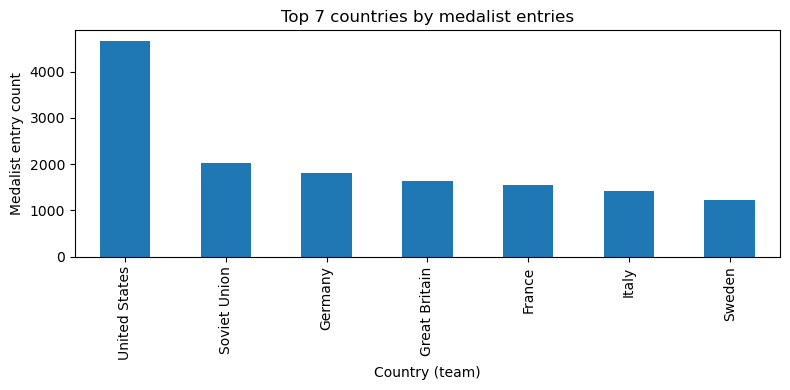

In [81]:
### Plot: Top 7 countries by medalist entries
top7 = country_medals.head(7)

plt.figure(figsize=(8,4))
top7.plot(kind="bar")
plt.title("Top 7 countries by medalist entries")
plt.xlabel("Country (team)")
plt.ylabel("Medalist entry count")
plt.tight_layout()
plt.savefig("figures/top7_countries_medals.png", dpi=300)
plt.show()


In [82]:
### Top 10 countries by medal type (Gold/Silver/Bronze) + one summary table
gold = medalists[medalists["medal"]=="Gold"].groupby("team").size().sort_values(ascending=False).head(10)
silver = medalists[medalists["medal"]=="Silver"].groupby("team").size().sort_values(ascending=False).head(10)
bronze = medalists[medalists["medal"]=="Bronze"].groupby("team").size().sort_values(ascending=False).head(10)

pd.DataFrame({"Gold": gold, "Silver": silver, "Bronze": bronze}).fillna(0).astype(int)


,Gold,Silver,Bronze
team,,,
Australia,0,406,486
Canada,0,355,383
China,359,0,0
France,474,502,568
Germany,613,579,608
Great Britain,507,571,548
Hungary,372,0,0
Italy,495,467,467
Russia,349,368,365


# Research Question 1
## Demographics and medal outcomes: age groups, sex, parity trends, and peak-age patterns

**Main question:**
**How do medal out-comes vary by age group and sex across sports, and which sports show the largest changes in gender parity and peak-age patterns across decades?**

We split Research quesion into three focused sub-questions so each is supported by clear plots:
- **RQ1(a):** How do medal outcomes vary by **age group** and **sex**?
- **RQ1(b):** Which decades show the **largest changes in gender parity** (male vs female shares)?
- **RQ1(c):** How do **peak-age patterns** change across decades (median + IQR of medalist ages)?

Run the cells in order.


### RQ1-1: Import libraries + folders

In [83]:
# RQ1-1) Imports(run once)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("figures", exist_ok=True)


### RQ1-2: Standardize column names + create helper columns

In [84]:
# RQ1-2) Standardize column names + check required columns + create decade + pick age column
df_clean = df.copy()
# 1) Standardize column names (safe even if already standardized)
df_clean.columns = [c.strip().lower().replace(" ", "_") for c in df_clean.columns]

# 2) Check required columns exist (IMPORTANT: usually it's "sport", not "sports")
required = ["year", "sex", "sports", "medal"]

missing = [c for c in required if c not in df_clean.columns]

if not missing:
    print("There are no missing required columns.")
else:
    print("Missing required columns:", missing)

# 3) Create decade column (for decade-level trend analysis)
df_clean["decade"] = (df_clean["year"] // 10) * 10

# 4) Choose which age column to use (prefer imputed age if available)
if "age_imputed" in df_clean.columns:
    age_col = "age_imputed"
elif "age" in df_clean.columns:
    age_col = "age"
else:
    age_col = None

print("Using age column:", age_col)



There are no missing required columns.
Using age column: age_imputed


### RQ1-3: Create age groups (Olympics-style bins for convenient interpretation)

In [85]:
# RQ1-3) Create age groups 
age_order = ["<16", "16-18", "19-25", "26-30", "31-35", "36-40", "41-50", "51+"]

if "age_group" not in df_clean.columns:
    if age_col is None:
        print("No age column available.")
    else:
        bins = [0, 15, 18, 25, 30, 35, 40, 50, 100]
        df_clean["age_group"] = pd.cut(df_clean[age_col], bins=bins, labels=age_order, right=True)

# Force consistent category order for plotting
if "age_group" in df_clean.columns:
    df_clean["age_group"] = pd.Categorical(df_clean["age_group"], categories=age_order, ordered=True)

print(df_clean["age_group"].value_counts(dropna=False).sort_index())


age_group
<16        2917
16-18     16230
19-25    122217
26-30     69066
31-35     28137
36-40      9495
41-50      5593
51+        1474
Name: count, dtype: int64


### RQ1-4: Create medalists subset (Gold/Silver/Bronze only)

In [86]:
# RQ1-4) Create a "medalists" subset
# Purpose: keep ONLY rows where the athlete won a medal (Gold/Silver/Bronze).
# This is useful for analyses that focus on medal outcomes (not participation without medals).

medalists = df_clean[df_clean["medal"].isin(["Gold", "Silver", "Bronze"])].copy()

# Print the shape (rows, columns) so you know how big the medalist-only dataset is.
print("Medalist rows (rows, cols):", medalists.shape)

Medalist rows (rows, cols): (36217, 14)


## RQ1a Plot 1 — 100% stacked bar: medalist sex composition by age group
### 1) What this shows:
###   For each age group, this chart displays the percentage of medal-winning entries
###  that are Female (F) vs Male (M). Each bar sums to 100%.
### 2) Why we use it:
###  A normal count-based stacked bar can hide smaller groups (e.g., 41+ females) because
### some age groups have many more medalists overall. Using percentages makes the
### M vs F comparison fair and easy across all age groups.

C:\Users\princ\AppData\Local\Temp\ipykernel_33624\2833649052.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medalists.groupby(["age_group", "sex"])


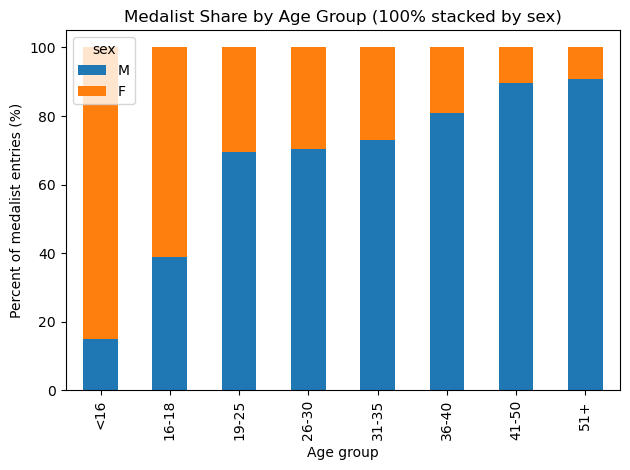

In [87]:
tab = (
    medalists.groupby(["age_group", "sex"])
    .size()
    .unstack(fill_value=0)
)

# Ensure both sex columns exist (prevents errors if one category is missing)
for s in ["M", "F"]:
    if s not in tab.columns:
        tab[s] = 0

# Keep the age groups in the correct order
tab = tab[["M", "F"]].reindex(age_order)

# Convert counts to percentages within each age group
prop = tab.div(tab.sum(axis=1), axis=0) * 100

ax = prop.plot(kind="bar", stacked=True)
ax.set_title("Medalist Share by Age Group (100% stacked by sex)")
ax.set_xlabel("Age group")
ax.set_ylabel("Percent of medalist entries (%)")
plt.tight_layout()
plt.savefig("figures/RQ1a_plot1_100pct_stacked_agegroup_sex.png", dpi=300)
plt.show()

In [88]:
### Interpretation (RQ1a Plot 1: 100% stacked sex share by age group)
### What it means:
### - Each bar = one age group.
### - The bar shows the percentage of medalist entries that are Female vs Male in that age group.
### - This lets us compare sex balance across age groups fairly (even when some age groups are small).
###
### Key takeaway:
### - Identify age groups where female representation among medalists is higher/lower.
###
### What surprised us:
### - If very young (<16) or older (41+, 51+) groups are heavily skewed, it suggests certain sports/eras
###   produce medalists that are mostly one sex at those ages.
###
### Limitations:
### - This is medalist entries only, not all athletes.
### - Team events can inflate medalist entries (multiple athletes for one medal).
### - Age is imputed for some rows (age_imputed), which can slightly smooth real variation.

# Quick numeric summary 
prop_summary = prop.copy()
prop_summary["Female_minus_Male"] = prop_summary["F"] - prop_summary["M"]
prop_summary.sort_values("Female_minus_Male", ascending=False).head(3)

prop_summary.sort_values("Female_minus_Male").head(3)

sex,M,F,Female_minus_Male
age_group,,,
51+,90.909091,9.090909,-81.818182
41-50,89.537713,10.462287,-79.075426
36-40,80.959198,19.040802,-61.918397


## RQ1a Plot 2 — 100% stacked bar: medal type composition by age group
### 1) What this shows:
### For each age group, this chart shows the percentage breakdown of medal outcomes
### (Gold vs Silver vs Bronze) among medal-winning entries. Each bar sums to 100%.
### 2) Why we use it:
### Total medal counts can vary a lot across age groups. Using shares lets us compare
### whether some age groups tend to win a higher proportion of Gold (or Bronze, etc.)
### relative to other age groups.

C:\Users\princ\AppData\Local\Temp\ipykernel_33624\3386576969.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medalists.groupby(["age_group", "medal"])


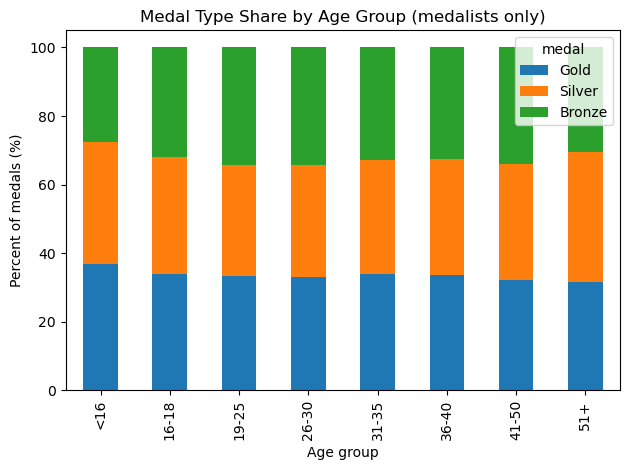

In [89]:
medal_tab = (
    medalists.groupby(["age_group", "medal"])
    .size()
    .unstack(fill_value=0)
)

# Ensure all medal categories exist (prevents KeyErrors if one is missing)
for m in ["Gold", "Silver", "Bronze"]:
    if m not in medal_tab.columns:
        medal_tab[m] = 0

# Keep a consistent medal order + age group order
medal_tab = medal_tab[["Gold", "Silver", "Bronze"]].reindex(age_order)

# Convert counts to percentages within each age group
medal_share = medal_tab.div(medal_tab.sum(axis=1), axis=0) * 100

ax = medal_share.plot(kind="bar", stacked=True)
ax.set_title("Medal Type Share by Age Group (medalists only)")
ax.set_xlabel("Age group")
ax.set_ylabel("Percent of medals (%)")
plt.tight_layout()
plt.savefig("figures/RQ1a_plot2_medal_type_share_by_agegroup.png", dpi=300)
plt.show()


In [90]:
### Interpretation (RQ1a Plot 2: medal type share by age group)
### What it means:
### - Each bar = one age group, and it sums to 100%.
### - The colors show how medals in that age group split into Gold vs Silver vs Bronze.
### - This helps check if some age groups have relatively more Gold (or Bronze), not just more medals.
###
### Key takeaway:
### - If Gold share is higher in certain age groups, that age range may align with peak performance.
###
### What surprised us:
### - If the Gold/Silver/Bronze shares look nearly constant across age groups, it suggests age affects
###   "how many medals happen" more than "which medal type happens."
###
### Limitations:
### - Medal type shares do NOT show the total number of medals (a small age group can still be 100%).
### - This is not causal: age does not "cause" medal type; sport, era, and competition depth matter.

# Quick numeric check: which age group has highest Gold share?
gold_by_age = medal_share["Gold"].sort_values(ascending=False)
gold_by_age.head(3), gold_by_age.tail(3)

(age_group
 <16      36.956522
 31-35    34.012360
 16-18    33.792240
 Name: Gold, dtype: float64,
 age_group
 26-30    32.950865
 41-50    32.116788
 51+      31.578947
 Name: Gold, dtype: float64)

# RQ1b Plot 3 — Gender parity over decades (male + female share on the same chart)
### 1) What this shows:
### This plot tracks how the share of Olympic entries changes over time for Female (F) and Male (M)
### athletes. Values are computed within each decade, so the lines represent long-term trends.
### 2) How to interpret:
### - A value of 0.50 means perfect parity (equal female and male representation).
### - As the female share rises toward 0.50, the Olympics become more gender-balanced.
### 3) Why we use decades:
### Using decades smooths out year-to-year noise and makes the overall trend easier to see.

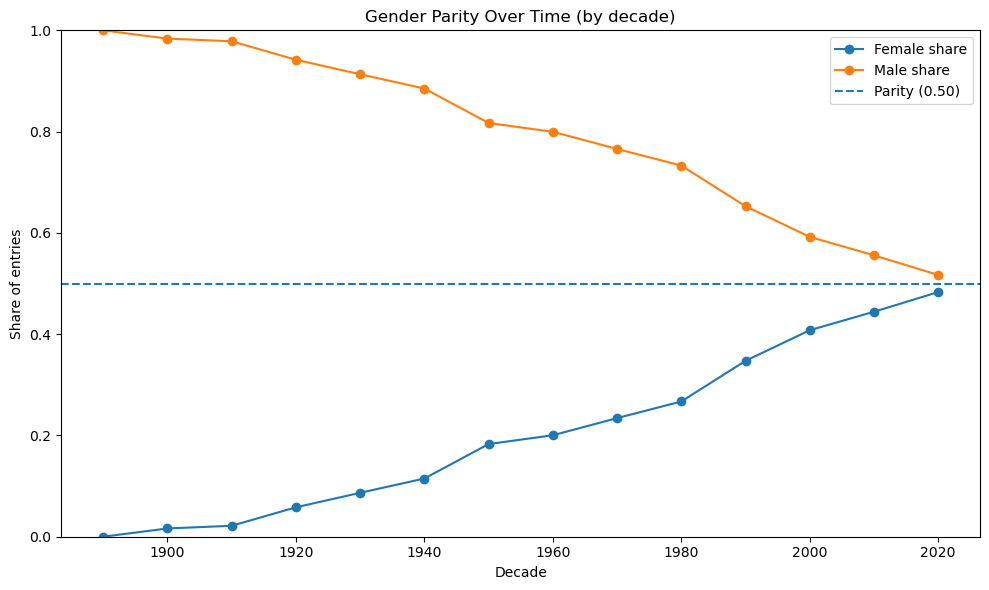

In [91]:
tmp = df_clean.dropna(subset=["decade", "sex"]).copy()

# Count entries by decade and sex
parity = (
    tmp.groupby(["decade", "sex"])
    .size()
    .unstack(fill_value=0)
)

# Ensure both categories exist (prevents errors if a decade has only one sex)
for s in ["M", "F"]:
    if s not in parity.columns:
        parity[s] = 0

# Convert counts to shares within each decade
parity["female_share"] = parity["F"] / (parity["F"] + parity["M"])
parity["male_share"]   = parity["M"] / (parity["F"] + parity["M"])

plt.figure(figsize=(10,6))
plt.plot(parity.index, parity["female_share"], marker="o", label="Female share")
plt.plot(parity.index, parity["male_share"], marker="o", label="Male share")
plt.axhline(0.5, linestyle="--", label="Parity (0.50)")

plt.title("Gender Parity Over Time (by decade)")
plt.xlabel("Decade")
plt.ylabel("Share of entries")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.savefig("figures/RQ1b_plot3_gender_parity_by_decade.png", dpi=300)
plt.show()

In [92]:
### Interpretation (RQ1b Plot 3: gender parity over decades)
### What it means:
### - Each point is a decade.
### - Female share shows what fraction of entries are female in that decade.
### - Male share is the remainder (1 - female share).
### - The dashed 0.50 line is perfect parity.
###
### Key takeaway:
### - The long-term trend shows whether Olympics move toward gender balance over time.
###
### What surprised us:
### - If there are decades with plateaus or temporary reversals, it may reflect historical events,
###   changes in included events, or reporting/coverage differences.
###
### Limitations:
### - This measures participation entries, not medals.
### - Dataset composition (Summer/Winter mix, missing years, etc.) can affect the curve.
### - It does not explain why parity changes; it only shows the pattern.

# Quick summary: female share first decade vs last decade
female_start = parity["female_share"].dropna().iloc[0]
female_end = parity["female_share"].dropna().iloc[-1]
print("Female share: first decade =", round(float(female_start), 3), "| last decade =", round(float(female_end), 3))
print("Change (last - first) =", round(float(female_end - female_start), 3))

Female share: first decade = 0.0 | last decade = 0.483
Change (last - first) = 0.483


### RQ1b Plot 4 — Largest decade-to-decade changes in female participation share
### 1) What this shows:
### This plot measures how much the female participation share changes from one decade to the next.
### We use the absolute value so we focus on the size of the change (largest shifts), not direction.
### - The size of the shift in female representation between consecutive decades
### - Peaks highlight decades with the biggest parity changes
###
### 2) How to interpret:
### - Higher points indicate decades where gender representation shifted the most.
### - These decades contributed most to movement toward (or away from) parity.
###
### 3) Why this plot:
### - Female share is the standard way to report gender parity.
### - Male share is redundant because male_share = 1 - female_share, so the change plot is identical.


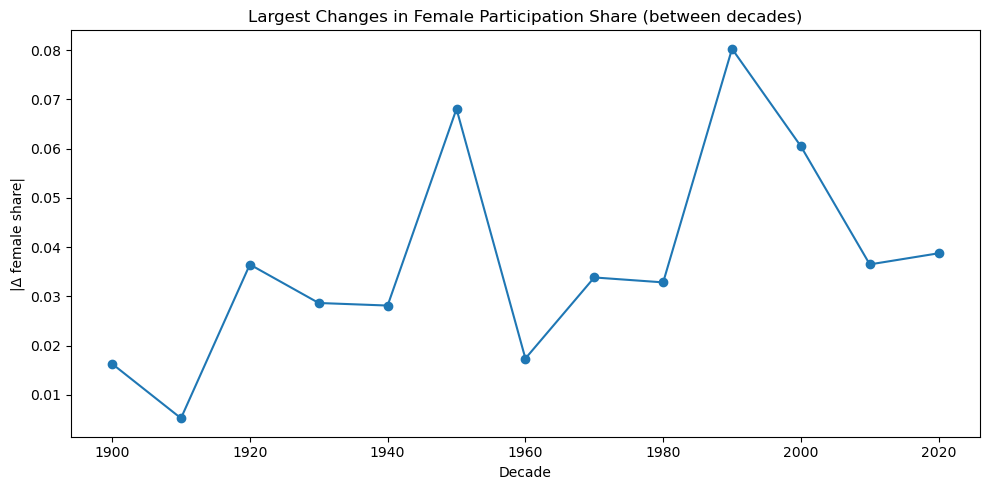

decade
1990    0.080276
1950    0.068075
2000    0.060473
2020    0.038764
2010    0.036503
Name: female_share, dtype: float64

In [93]:
# Absolute change in female share between consecutive decades
parity_change_f = parity["female_share"].diff().abs()

plt.figure(figsize=(10,5))
plt.plot(parity_change_f.index, parity_change_f.values, marker="o")
plt.title("Largest Changes in Female Participation Share (between decades)")
plt.xlabel("Decade")
plt.ylabel("|Δ female share|")
plt.tight_layout()
plt.savefig("figures/RQ1b_plot4_abs_change_female_share.png", dpi=300)
plt.show()

# Top 5 decades with the largest changes (table for reporting)
top5_f = parity_change_f.sort_values(ascending=False).head(5)
top5_f

In [94]:
### Interpretation (RQ1b Plot 4: largest changes in female participation share)
### What it means:
### - Each point measures how much female share changed from the previous decade.
### - We use absolute change |Δ| so we highlight the biggest shifts, regardless of direction.
###
### Key takeaway:
### - Peaks identify the decades where gender representation changed the most.
### - These are the key “transition periods” in gender inclusion.
###
### What surprised us:
### - If the biggest jumps cluster in a certain era, it suggests policy/event expansion effects.
###
### Limitations:
### - Changes can be affected by which editions are present in the dataset for a decade.
### - This is participation share, not medal share.
### - Male change is identical in magnitude (male_share = 1 - female_share), so we only report female.

# Report-friendly: show the top 5 decades with biggest shifts
top5_f

decade
1990    0.080276
1950    0.068075
2000    0.060473
2020    0.038764
2010    0.036503
Name: female_share, dtype: float64

### RQ1c (ONE PLOT): Peak-age patterns across decades using ALL sports together
### Plot: Median + IQR of medalist ages by decade (Female vs Male)
###
### Research goal (simple):
### Instead of choosing one sport, we combine medalists from ALL sports to get one overall view of
### how the “typical” medalist age changes across decades for females and males.
###
### Key terms (definitions):
### 1) Medalist:
###    - A row is a medalist if medal ∈ {Gold, Silver, Bronze}.
### 2) Decade:
###    - We group years into decades (example: 1992 → 1990s) to smooth long-term trends.
### 3) Median age:
###    - The middle value after sorting ages (robust to outliers).
###    - Used as a proxy for the “typical” (peak) medal-winning age in that decade.
### 4) IQR (Interquartile Range):
###    - Q1 = 25th percentile, Q3 = 75th percentile.
###    - The shaded band (Q1 to Q3) shows the typical spread (middle 50%) of medalist ages.
###
### What this plot shows:
### - Female and male median medalist age by decade (lines)
### - Female and male IQR bands by decade (shading)
###
### Why this approach:
### - It avoids cherry-picking a single sport.
### - It provides one clean plot you can include in the report.


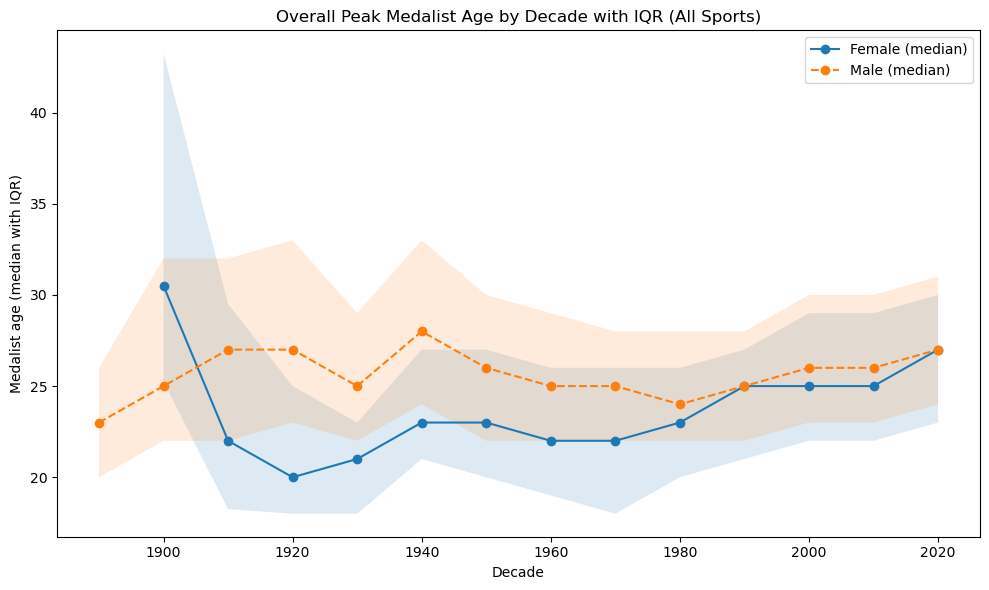

In [95]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)

# Step 0) Check that we have an age column available
if age_col is None:
    print("No age column available for peak-age analysis.")
else:
    # Step 1) Keep only medalist rows with valid ages (drop missing ages)
    medalists_age = medalists.dropna(subset=[age_col]).copy()

    # Step 2) Helper function: compute median + IQR by decade for one sex (ALL sports combined)
    def decade_quantiles(df, sex_value):
        sub = df[df["sex"] == sex_value]
        g = sub.groupby("decade")[age_col]
        out = pd.DataFrame({
            "median": g.median(),
            "q25": g.quantile(0.25),
            "q75": g.quantile(0.75),
            "n": g.size()
        }).reset_index().sort_values("decade")
        return out

    # Step 3) Compute decade summaries for females and males
    F = decade_quantiles(medalists_age, "F")
    M = decade_quantiles(medalists_age, "M")

    # Step 4) Plot median lines + IQR bands
    plt.figure(figsize=(10, 6))

    if len(F) > 0:
        plt.fill_between(F["decade"], F["q25"], F["q75"], alpha=0.15)
        plt.plot(F["decade"], F["median"], marker="o", label="Female (median)")

    if len(M) > 0:
        plt.fill_between(M["decade"], M["q25"], M["q75"], alpha=0.15)
        plt.plot(M["decade"], M["median"], marker="o", linestyle="--", label="Male (median)")

    plt.title("Overall Peak Medalist Age by Decade with IQR (All Sports)")
    plt.xlabel("Decade")
    plt.ylabel("Medalist age (median with IQR)")
    plt.legend()
    plt.tight_layout()

    # Step 5) Save figure for Overleaf
    plt.savefig("figures/plot5.png", dpi=300)
    plt.show()

    # Step 6) (Optional) Show sample size per decade for reporting
    # This table helps explain which decades have more/less data.
    F[["decade", "n"]].rename(columns={"n": "female_n"}).merge(
        M[["decade", "n"]].rename(columns={"n": "male_n"}),
        on="decade",
        how="outer"
    ).fillna(0).astype({"female_n": int, "male_n": int})

In [96]:
### Interpretation (RQ1c Plot 5: overall peak medalist age by decade with IQR, all sports)
### What it means:
### - The solid/dashed lines show the typical (median) medalist age for females and males by decade.
### - The shaded area is the IQR (middle 50% of medalist ages), showing how spread out ages are.
### - Because we combine all sports, this gives one clean “overall Olympics” age pattern.
###
### Key takeaway:
### - If the median age rises, it suggests medal-winning ages are getting older over time.
### - If the IQR widens, it suggests a broader range of ages win medals in that era.
###
### What surprised us:
### - Early decades may show unstable patterns due to very low female participation (small sample size).
### - Some decades might show sudden shifts due to changes in Olympic participation or event structure.
###
### Limitations:
### - Combining all sports hides sport-specific peak ages (gymnastics vs rowing differ a lot).
### - Team events can inflate medalist rows.
### - Age imputation can smooth the trend slightly.
### - Early decades for women may be less reliable if female sample size is small.

# Simple numeric summary: female vs male overall median (all decades pooled)
overall_f_med = medalists_age[medalists_age["sex"]=="F"][age_col].median()
overall_m_med = medalists_age[medalists_age["sex"]=="M"][age_col].median()
print("Overall median medalist age (Female):", round(float(overall_f_med), 2))
print("Overall median medalist age (Male):  ", round(float(overall_m_med), 2))

Overall median medalist age (Female): 25.0
Overall median medalist age (Male):   26.0


### RQ1-5 Export summary tables used in RQ1

In [97]:
### Optional: Export small tables for the report appendix (RQ1)

import os
os.makedirs("outputs", exist_ok=True)

# 1) Export gender-parity-by-decade table (used in RQ1b plots)
if "parity" in locals():
    parity.reset_index().to_csv("outputs/rq1_parity_by_decade.csv", index=False)
    print("Saved: outputs/rq1_parity_by_decade.csv")
else:
    print("Skip parity export: 'parity' not found (run RQ1b Plot 3 first).")

# 2) Export peak-age (median + IQR) by decade (ALL sports combined, used in RQ1c Plot 5)
# This requires that RQ1c created F and M tables in the current session.
if all(x in locals() for x in ["F", "M"]) and (age_col is not None):
    peak_export = pd.concat(
        [
            F.assign(sex="F"),
            M.assign(sex="M")
        ],
        ignore_index=True
    )
    peak_export.to_csv("outputs/rq1_peak_age_iqr_by_decade_all_sports.csv", index=False)
    print("Saved: outputs/rq1_peak_age_iqr_by_decade_all_sports.csv")
else:
    print("Skip peak-age export: F/M tables not found or age_col is None (run RQ1c Plot 5 first).")

Saved: outputs/rq1_parity_by_decade.csv
Skip peak-age export: F/M tables not found or age_col is None (run RQ1c Plot 5 first).


# Research Question 2
## Medal-table definitions, ranking changes, and efficiency over time

**Main question:**
**How do Olympic medal tables change when we count medals per athlete versus per event, and which countries become more or less “medal-efficient” over time when we account for participation size?**

### Sub-questions
- **SQ1 (Inflation):** Which countries gain the most medals under athlete-based counting compared to event-based counting?
- **SQ2 (Ranking change):** Which countries move up or down in the rankings when we switch counting methods?
- **SQ3 (Efficiency):** Which countries convert participation into medals most efficiently under event-based counting?
- **SQ4 (Over time):** Do inflation and efficiency patterns change across decades?

Run cells in order. Each plot is in its own cell and matches one sub-question.


### RQ2-1: Imports + folders

In [98]:
# RQ2-1) Imports (run once)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re

os.makedirs("figures", exist_ok=True)
os.makedirs("outputs", exist_ok=True)


### RQ2-2: Standardize columns + create decade

In [99]:
# RQ2-2) Standardize column names (safe even if already done)
df_clean.columns = [c.strip().lower().replace(" ", "_") for c in df_clean.columns]

required = ["year", "team", "event", "medal"]
missing = [c for c in required if c not in df_clean.columns]
print("Missing required columns:", missing)

# Decade for time-based comparisons
df_clean["decade"] = (df_clean["year"] // 10) * 10
print("Year range:", df_clean["year"].min(), "to", df_clean["year"].max())


Missing required columns: []
Year range: 1896 to 2024


### RQ2-3: Clean team names (country-like grouping)

In [100]:
# RQ2-3) Clean team names to make country comparisons interpretable
df2 = df_clean.copy()

# Remove suffixes like '-1', '-2' (e.g., 'India-1' -> 'India')
df2["team_clean"] = df2["team"].astype(str).str.replace(r"-\d+$", "", regex=True).str.strip()

# Remove obvious non-country patterns (keep this list minimal + transparent)
bad_patterns = ["Boat", "Club", "Vesper", "Magda", "Union des", "Athletes"]
mask_bad = df2["team_clean"].str.contains("|".join(bad_patterns), case=False, na=False)

df2 = df2[~mask_bad].copy()

print("Example cleaned teams:", df2["team_clean"].dropna().unique()[:10])
print("Rows after team cleaning:", df2.shape)


Example cleaned teams: ['Great Britain' 'Latvia' 'Austria' 'Netherlands' 'Sweden' 'Japan' 'Italy'
 'Uruguay' 'United States' 'Denmark']
Rows after team cleaning: (254809, 15)


### RQ2-4: Build medal tables (athlete-medal vs event-medal) + entries

In [101]:
# RQ2-4) Build the two medal-counting methods and participation entries

# Medalists only (row-based athlete medals)
medalists = df2[df2["medal"].isin(["Gold", "Silver", "Bronze"])].copy()

# Event medals: count each (year, event, country/team_clean, medal) once
event_medals = medalists.drop_duplicates(["year", "event", "team_clean", "medal"]).copy()

print("Medalist rows (athlete-medal):", medalists.shape)
print("Event-medal rows:", event_medals.shape)

# Country-level totals (all years)
entries_all = df2.groupby("team_clean").size().rename("entries")
ath_all = medalists.groupby("team_clean").size().rename("athlete_medals")
evt_all = event_medals.groupby("team_clean").size().rename("event_medals")

summary_all = pd.concat([entries_all, ath_all, evt_all], axis=1).fillna(0)
summary_all["athlete_medals"] = summary_all["athlete_medals"].astype(int)
summary_all["event_medals"] = summary_all["event_medals"].astype(int)

summary_all.head()


Medalist rows (athlete-medal): (36037, 15)
Event-medal rows: (20838, 15)


,entries,athlete_medals,event_medals
team_clean,,,
30. Februar,2,0,0
A North American Team,3,3,1
AIN,32,4,4
Acipactli,3,0,0
Acturus,1,0,0


### RQ2-5: Filter to stable countries (avoid tiny-sample noise)

In [102]:
# RQ2-5) Filter to countries with enough data for stable comparisons
summary = summary_all[(summary_all["entries"] >= 500) & (summary_all["event_medals"] >= 20)].copy()
print("Countries kept after filtering:", summary.shape[0])


Countries kept after filtering: 65


## SQ1 Plot: Athlete-based inflation (athlete medals − event medals)

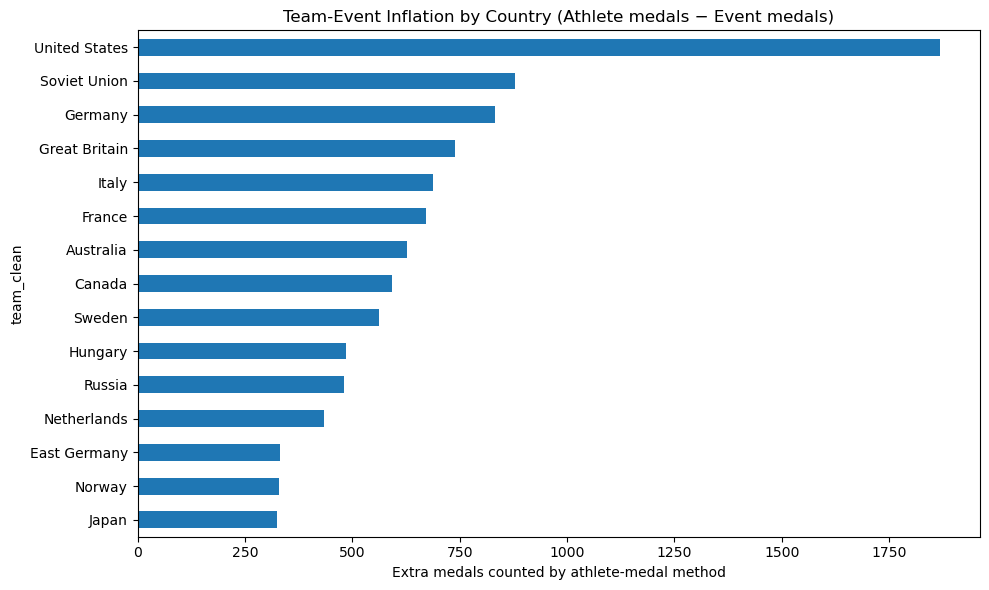

In [103]:
# SQ1 Plot) Inflation score
summary["inflation"] = summary["athlete_medals"] - summary["event_medals"]
top_inflation = summary.sort_values("inflation", ascending=False).head(15)["inflation"]

plt.figure(figsize=(10,6))
top_inflation.sort_values().plot(kind="barh")
plt.title("Team-Event Inflation by Country (Athlete medals − Event medals)")
plt.xlabel("Extra medals counted by athlete-medal method")
plt.tight_layout()
plt.savefig("figures/RQ2_SQ1_inflation_athlete_minus_event.png", dpi=300)
plt.show()


## SQ2 Plot: Rank changes when switching medal definitions (slope chart, one decade)

In [104]:
# Choose a decade (most recent by default)
decade_choice = int(df2["decade"].max())
print("Decade used:", decade_choice)

# Add decade columns to medal tables
medalists["decade"] = (medalists["year"] // 10) * 10
event_medals["decade"] = (event_medals["year"] // 10) * 10

df_dec = df2[df2["decade"] == decade_choice].copy()
med_dec = medalists[medalists["decade"] == decade_choice].copy()
evt_dec = event_medals[event_medals["decade"] == decade_choice].copy()

entries_d = df_dec.groupby("team_clean").size().rename("entries")
ath_d = med_dec.groupby("team_clean").size().rename("athlete_medals")
evt_d = evt_dec.groupby("team_clean").size().rename("event_medals")

dec = pd.concat([entries_d, ath_d, evt_d], axis=1).fillna(0)
dec["athlete_medals"] = dec["athlete_medals"].astype(int)
dec["event_medals"] = dec["event_medals"].astype(int)

# Filter for stability in this decade
dec = dec[(dec["entries"] >= 200) & (dec["event_medals"] >= 5)].copy()

# Ranks (1 = best)
dec["rank_athlete"] = dec["athlete_medals"].rank(ascending=False, method="dense")
dec["rank_event"] = dec["event_medals"].rank(ascending=False, method="dense")

# Take top 15 by event medals
top15 = dec.sort_values("event_medals", ascending=False).head(15).copy()
top15


Decade used: 2020


,entries,athlete_medals,event_medals,rank_athlete,rank_event
team_clean,,,,,
United States,1297,324,188,1.0,1.0
China,835,189,145,2.0,2.0
Japan,1129,162,110,5.0,3.0
Great Britain,844,172,107,3.0,4.0
France,1060,170,87,4.0,5.0
Australia,999,145,84,6.0,6.0
Italy,939,116,81,9.0,7.0
Germany,1051,123,78,8.0,8.0
Russia,501,129,68,7.0,9.0


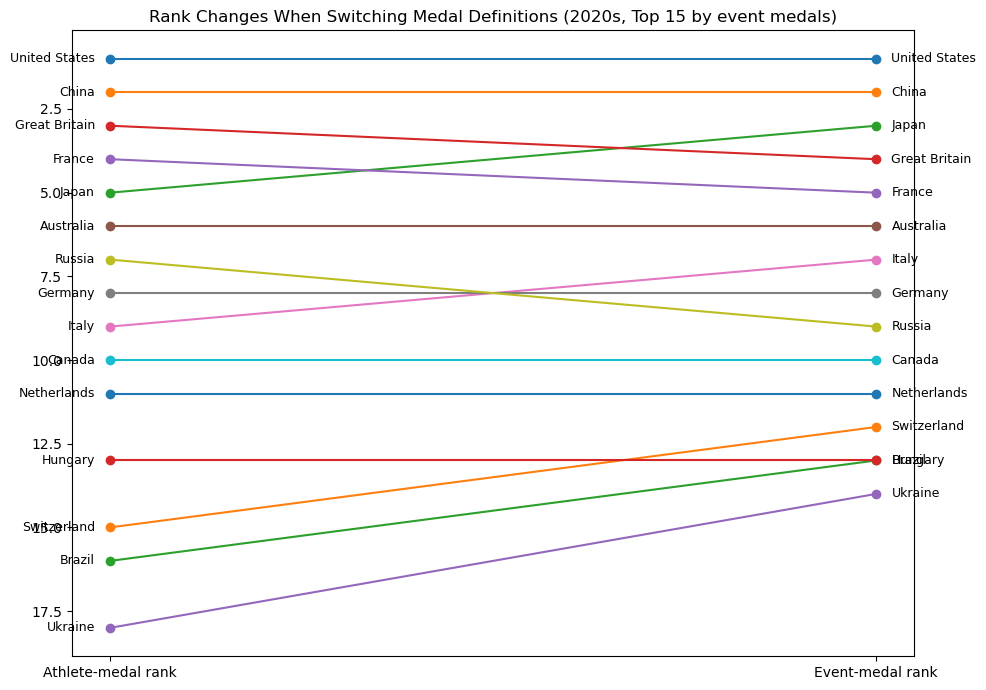

In [105]:
# SQ2 Plot) Slope chart: rank_athlete -> rank_event (top 15)
plot_df = top15.sort_values("rank_event", ascending=True)

plt.figure(figsize=(10,7))

for country in plot_df.index:
    ra = plot_df.loc[country, "rank_athlete"]
    re_ = plot_df.loc[country, "rank_event"]
    plt.plot([0, 1], [ra, re_], marker="o")

plt.xticks([0, 1], ["Athlete-medal rank", "Event-medal rank"])
plt.gca().invert_yaxis()

for country in plot_df.index:
    ra = plot_df.loc[country, "rank_athlete"]
    re_ = plot_df.loc[country, "rank_event"]
    plt.text(-0.02, ra, country, ha="right", va="center", fontsize=9)
    plt.text(1.02, re_, country, ha="left", va="center", fontsize=9)

plt.title(f"Rank Changes When Switching Medal Definitions ({decade_choice}s, Top 15 by event medals)")
plt.tight_layout()
plt.savefig("figures/RQ2_SQ2_slope_rank_change_one_decade.png", dpi=300)
plt.show()


## SQ3 Plot: Medal efficiency (event medals per 1000 entries)

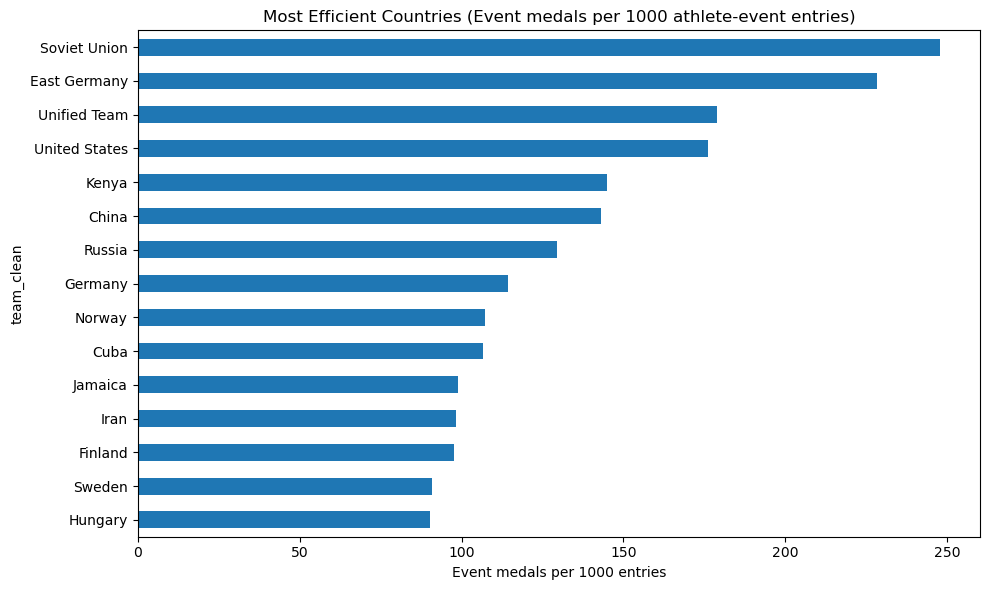

In [106]:
# SQ3 Plot) Efficiency = event medals per 1000 entries
summary["eff_event_per_1000"] = (summary["event_medals"] / summary["entries"]) * 1000
top_eff = summary.sort_values("eff_event_per_1000", ascending=False).head(15)["eff_event_per_1000"]

plt.figure(figsize=(10,6))
top_eff.sort_values().plot(kind="barh")
plt.title("Most Efficient Countries (Event medals per 1000 athlete-event entries)")
plt.xlabel("Event medals per 1000 entries")
plt.tight_layout()
plt.savefig("figures/RQ2_SQ3_efficiency_event_per_1000.png", dpi=300)
plt.show()


## SQ4 Plot: Inflation trend over decades

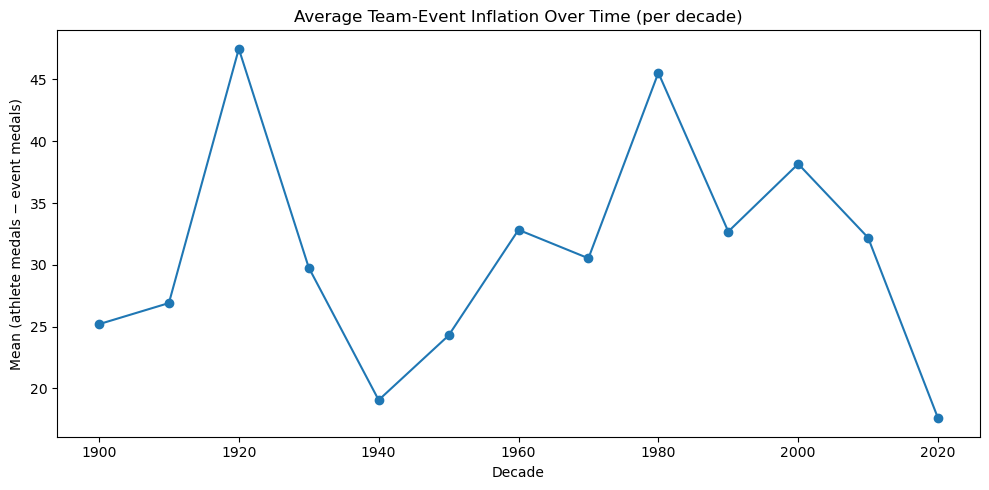

In [107]:
# SQ4 Plot) Average inflation per decade (athlete medals - event medals)

ath_dec = medalists.groupby(["decade","team_clean"]).size().rename("athlete_medals")
evt_dec = event_medals.groupby(["decade","team_clean"]).size().rename("event_medals")
ent_dec = df2.groupby(["decade","team_clean"]).size().rename("entries")

dec_tbl = pd.concat([ent_dec, ath_dec, evt_dec], axis=1).fillna(0)
dec_tbl["athlete_medals"] = dec_tbl["athlete_medals"].astype(int)
dec_tbl["event_medals"] = dec_tbl["event_medals"].astype(int)
dec_tbl["inflation"] = dec_tbl["athlete_medals"] - dec_tbl["event_medals"]

# Filter stable country-decades
dec_tbl = dec_tbl[(dec_tbl["entries"] >= 100) & (dec_tbl["event_medals"] >= 3)].copy()

trend = dec_tbl.groupby("decade")["inflation"].mean()

plt.figure(figsize=(10,5))
plt.plot(trend.index, trend.values, marker="o")
plt.title("Average Team-Event Inflation Over Time (per decade)")
plt.xlabel("Decade")
plt.ylabel("Mean (athlete medals − event medals)")
plt.tight_layout()
plt.savefig("figures/RQ2_SQ4_inflation_trend_by_decade.png", dpi=300)
plt.show()


## Additional RQ2 Visualizations (Variety)
These extra plots provide different perspectives (scatter, histogram, heatmap) to support RQ2.
Run them after the main SQ1–SQ4 plots.


### Extra Plot A: Athlete-medals vs Event-medals (scatter)
Shows how far countries deviate from the 1:1 line (team-event inflation).

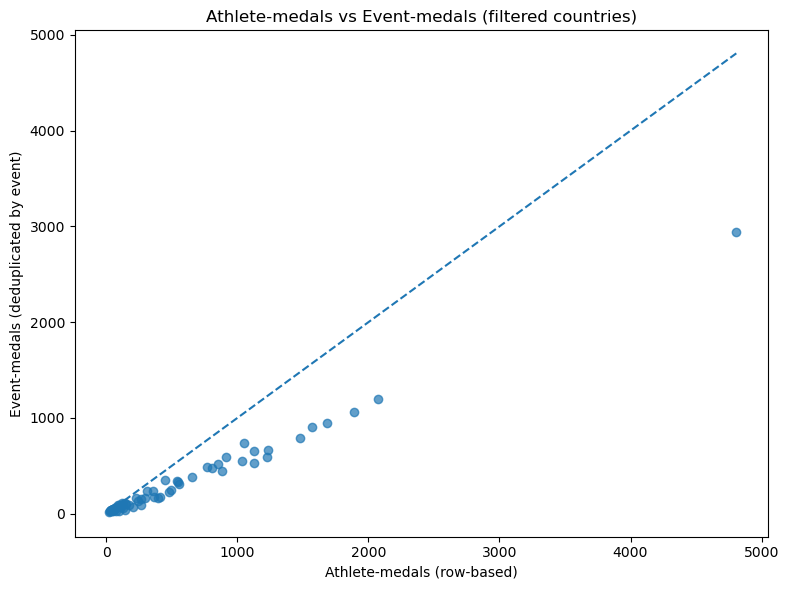

In [108]:
# Extra Plot A) Scatter: athlete_medals vs event_medals (all-years, filtered countries)

plt.figure(figsize=(8,6))
plt.scatter(summary["athlete_medals"], summary["event_medals"], alpha=0.7)

# 1:1 reference line
max_val = max(summary["athlete_medals"].max(), summary["event_medals"].max())
plt.plot([0, max_val], [0, max_val], linestyle="--")

plt.title("Athlete-medals vs Event-medals (filtered countries)")
plt.xlabel("Athlete-medals (row-based)")
plt.ylabel("Event-medals (deduplicated by event)")
plt.tight_layout()
plt.savefig("figures/RQ2_extraA_scatter_athlete_vs_event.png", dpi=300)
plt.show()


### Extra Plot B: Participation vs Efficiency (scatter)
Compares participation size (entries) with efficiency (event medals per 1000 entries).

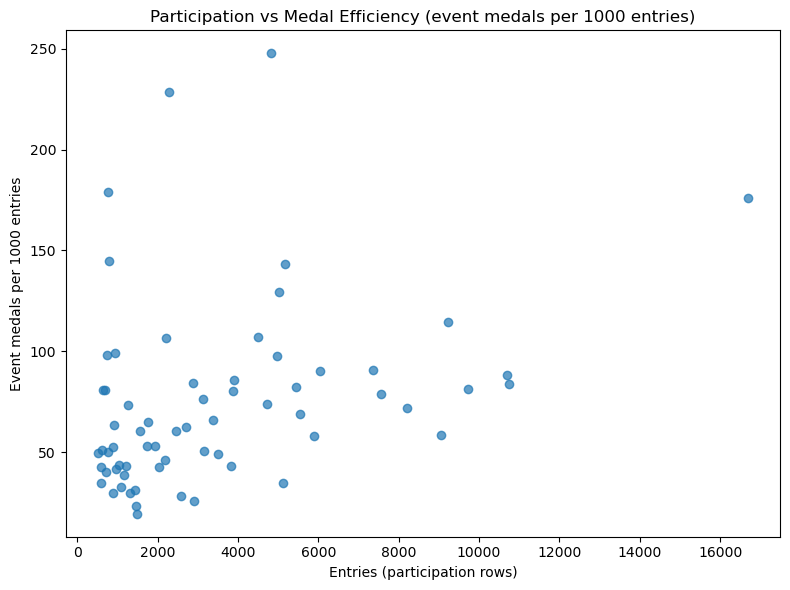

In [109]:
# Extra Plot B) Scatter: entries vs efficiency (event medals per 1000 entries)

plt.figure(figsize=(8,6))
plt.scatter(summary["entries"], summary["eff_event_per_1000"], alpha=0.7)

plt.title("Participation vs Medal Efficiency (event medals per 1000 entries)")
plt.xlabel("Entries (participation rows)")
plt.ylabel("Event medals per 1000 entries")
plt.tight_layout()
plt.savefig("figures/RQ2_extraB_scatter_entries_vs_efficiency.png", dpi=300)
plt.show()


### Extra Plot C: Distribution of rank changes (histogram)
Shows how common ranking changes are in the selected decade when switching methods.

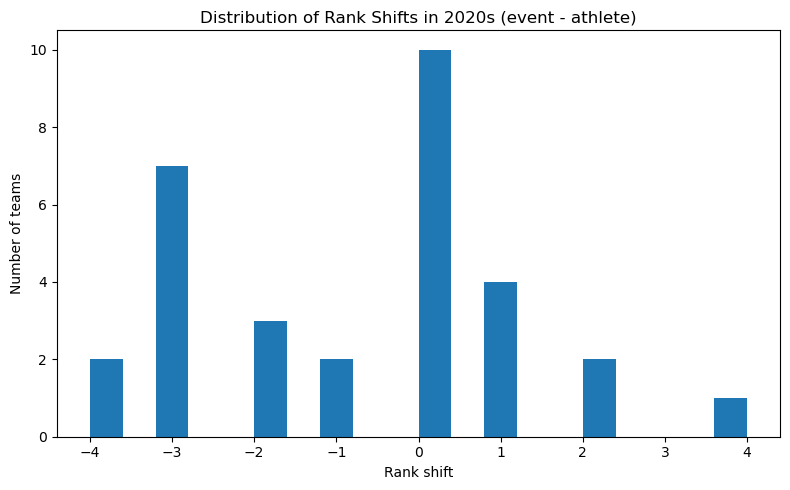

In [110]:
# Extra Plot C) Histogram of rank shifts in the chosen decade (all stable teams in that decade)

dec["rank_shift"] = dec["rank_event"] - dec["rank_athlete"]

plt.figure(figsize=(8,5))
plt.hist(dec["rank_shift"], bins=20)
plt.title(f"Distribution of Rank Shifts in {decade_choice}s (event - athlete)")
plt.xlabel("Rank shift")
plt.ylabel("Number of teams")
plt.tight_layout()
plt.savefig("figures/RQ2_extraC_hist_rank_shift_one_decade.png", dpi=300)
plt.show()


### Extra Plot D: Heatmap of rank shift across decades (top countries)
Visual summary of how rank changes vary across time for top medal countries.

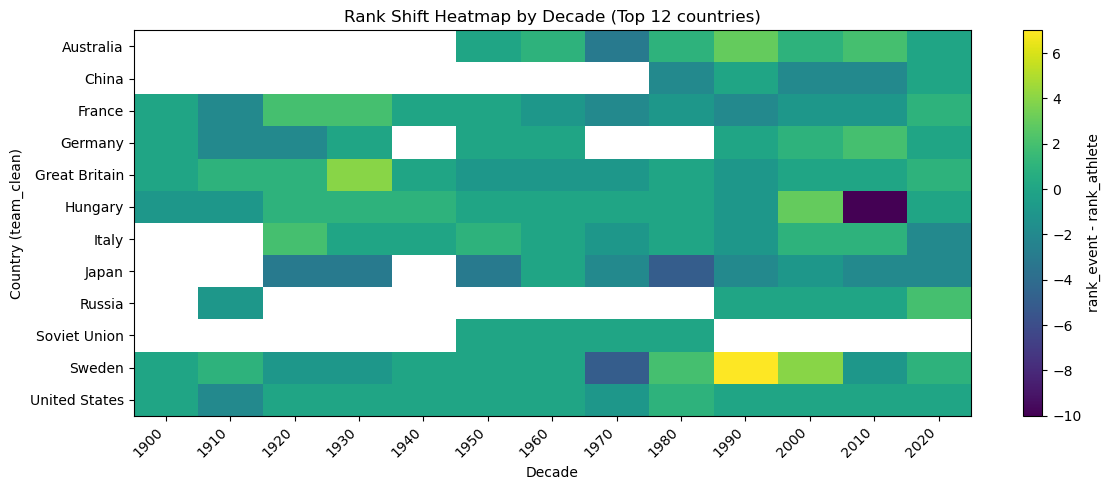

In [111]:
# Extra Plot D : Heatmap of rank shift across decades

# dec_tbl is likely a MultiIndex with (decade, team_clean) in the index,
# so convert it into real columns first:
dec_rank = dec_tbl.reset_index().copy()

# Rank within each decade using both counts
dec_rank["rank_athlete"] = dec_rank.groupby("decade")["athlete_medals"].rank(ascending=False, method="dense")
dec_rank["rank_event"]   = dec_rank.groupby("decade")["event_medals"].rank(ascending=False, method="dense")
dec_rank["rank_shift"]   = dec_rank["rank_event"] - dec_rank["rank_athlete"]

# Pick top 12 countries by total event medals
top_countries = (
    dec_rank.groupby("team_clean")["event_medals"].sum()
    .sort_values(ascending=False).head(12).index.tolist()
)

heat = (
    dec_rank[dec_rank["team_clean"].isin(top_countries)]
    .pivot_table(index="team_clean", columns="decade", values="rank_shift", aggfunc="mean")
)

plt.figure(figsize=(12,5))
plt.imshow(heat.values, aspect="auto", interpolation="nearest")
plt.title("Rank Shift Heatmap by Decade (Top 12 countries)")
plt.xlabel("Decade")
plt.ylabel("Country (team_clean)")
plt.xticks(range(len(heat.columns)), heat.columns, rotation=45, ha="right")
plt.yticks(range(len(heat.index)), heat.index)
plt.colorbar(label="rank_event - rank_athlete")
plt.tight_layout()
plt.savefig("figures/RQ2_extraD_heatmap_rank_shift_by_decade.png", dpi=300)
plt.show()

### Optional: Save extra summary outputs

In [112]:
# Optional exports for extra plots
heat.to_csv("outputs/rq2_rank_shift_heatmap_table.csv")
print("Saved outputs/rq2_rank_shift_heatmap_table.csv")


Saved outputs/rq2_rank_shift_heatmap_table.csv


### RQ2-6 (Optional): Export tables used in RQ2

In [113]:
# Optional exports
summary.to_csv("outputs/rq2_country_summary.csv", index=True)
top15.to_csv("outputs/rq2_top15_decade_rank_table.csv", index=True)
print("Saved outputs/rq2_country_summary.csv and outputs/rq2_top15_decade_rank_table.csv")


Saved outputs/rq2_country_summary.csv and outputs/rq2_top15_decade_rank_table.csv


# Research Question 3
## Diversification vs efficiency and rankings over time

**Main question:** Do countries win medals more efficiently when they spread success across many sports, or when they focus on a few sports—and how does this affect medal rankings over time?

### Sub-questions
- **RQ3a (Diversification):** How spread out are each country’s medals across sports?
- **RQ3b (Efficiency):** Are diversified countries more medal-efficient (event medals per participation)?
- **RQ3c (Rankings):** How does diversification relate to country rankings, and how do rankings evolve over decades?
- **RQ3d (Stability):** Are diversified countries more stable (less ups-and-downs) across decades?

**Goal:** Use all selected countries (target: 92) for overview plots, then analyze top/mid/bottom 20 based on efficiency.
Run cells in order.


### RQ3-1: Imports + folders

In [114]:
# RQ3-1) Imports (run once for RQ3)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re

os.makedirs("figures", exist_ok=True)
os.makedirs("outputs", exist_ok=True)


### RQ3-2: Prepare data (team cleaning + decade)

In [115]:
# RQ3-2) Prepare data
df = df_clean.copy()
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

# Decade for over-time analysis
df["decade"] = (df["year"] // 10) * 10

# Clean team names to reduce duplicates like 'India-1' vs 'India-2'
df["team_clean"] = df["team"].astype(str).str.replace(r"-\d+$", "", regex=True).str.strip()

print("Unique team_clean:", df["team_clean"].nunique())
print("Example team_clean:", df["team_clean"].dropna().unique()[:10])


Unique team_clean: 941
Example team_clean: ['Great Britain' 'Latvia' 'Austria' 'Netherlands' 'Sweden' 'Japan' 'Italy'
 'Uruguay' 'United States' 'Denmark']


### RQ3-3: Create medal tables (event-medal method)

In [116]:
# RQ3-3) Medalists and event-medals
medalists = df[df["medal"].isin(["Gold","Silver","Bronze"])].copy()

# Event medals: count each medal once per (year, event, country, medal)
event_medals = medalists.drop_duplicates(["year","event","team_clean","medal"]).copy()

print("Medalist rows:", medalists.shape)
print("Event-medal rows:", event_medals.shape)


Medalist rows: (36217, 15)
Event-medal rows: (20888, 15)


### RQ3-4: Build country summary metrics

In [117]:
# RQ3-4) Summary metrics per country

entries = df.groupby("team_clean").size().rename("entries")
event_counts = event_medals.groupby("team_clean").size().rename("event_medals")

# diversification metric (simple): how many sports with >=1 event medal
sports_medaled = event_medals.groupby("team_clean")["sports"].nunique().rename("sports_medaled")

summary = pd.concat([entries, event_counts, sports_medaled], axis=1).fillna(0)
summary["entries"] = summary["entries"].astype(int)
summary["event_medals"] = summary["event_medals"].astype(int)
summary["sports_medaled"] = summary["sports_medaled"].astype(int)

# Efficiency: event medals per 1000 entries
summary["eff_event_per_1000"] = (summary["event_medals"] / summary["entries"]) * 1000

summary.head()


,entries,event_medals,sports_medaled,eff_event_per_1000
team_clean,,,,
30. Februar,2,0,0,0.000000
A North American Team,3,1,1,333.333333
AIN,32,4,3,125.000000
Acipactli,3,0,0,0.000000
Acturus,1,0,0,0.000000


### RQ3-5: Compute concentration (HHI)

In [118]:
# RQ3-5) HHI concentration index (higher = more focused, lower = more diversified)

cs = event_medals.groupby(["team_clean","sports"]).size().rename("sport_medals").reset_index()
totals = cs.groupby("team_clean")["sport_medals"].sum().rename("total_medals")
cs = cs.merge(totals, on="team_clean", how="left")

cs["p"] = cs["sport_medals"] / cs["total_medals"]
hhi = cs.groupby("team_clean")["p"].apply(lambda x: (x**2).sum()).rename("HHI")

summary = summary.merge(hhi, on="team_clean", how="left").fillna({"HHI": 0})
summary.head()


,entries,event_medals,sports_medaled,eff_event_per_1000,HHI
team_clean,,,,,
30. Februar,2,0,0,0.000000,0.000
A North American Team,3,1,1,333.333333,1.000
AIN,32,4,3,125.000000,0.375
Acipactli,3,0,0,0.000000,0.000
Acturus,1,0,0,0.000000,0.000


### RQ3-6: Select 92 countries (stable & active)

In [119]:
# RQ3-6) Select exactly 92 countries for overview plots

# Filter tiny-sample noise (adjust thresholds if needed)
stable = summary[(summary["entries"] >= 300) & (summary["event_medals"] >= 10)].copy()

# Pick top 92 by entries (most active participants)
stable_92 = stable.sort_values("entries", ascending=False).head(92).copy()
print("Selected countries:", stable_92.shape[0])

stable_92.head()


Selected countries: 81


,entries,event_medals,sports_medaled,eff_event_per_1000,HHI
team_clean,,,,,
United States,16681,2939,64,176.188478,0.139371
France,10756,901,54,83.767200,0.061514
Great Britain,10691,944,57,88.298569,0.091831
Italy,9722,789,51,81.156141,0.063810
Germany,9238,1057,55,114.418705,0.046689


## RQ3 Plot 1 (All 92): Diversification vs efficiency (scatter)

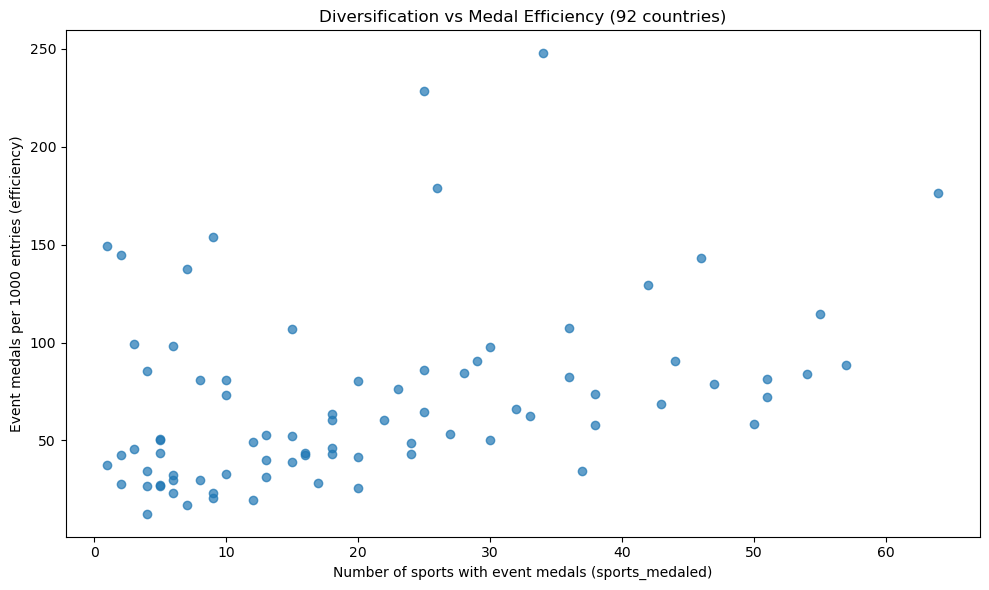

In [120]:
plt.figure(figsize=(10,6))
plt.scatter(stable_92["sports_medaled"], stable_92["eff_event_per_1000"], alpha=0.7)
plt.title("Diversification vs Medal Efficiency (92 countries)")
plt.xlabel("Number of sports with event medals (sports_medaled)")
plt.ylabel("Event medals per 1000 entries (efficiency)")
plt.tight_layout()
plt.savefig("figures/RQ3_plot1_scatter_sports_vs_efficiency.png", dpi=300)
plt.show()


## RQ3 Plot 2 (All 92): Concentration (HHI) vs efficiency (scatter)

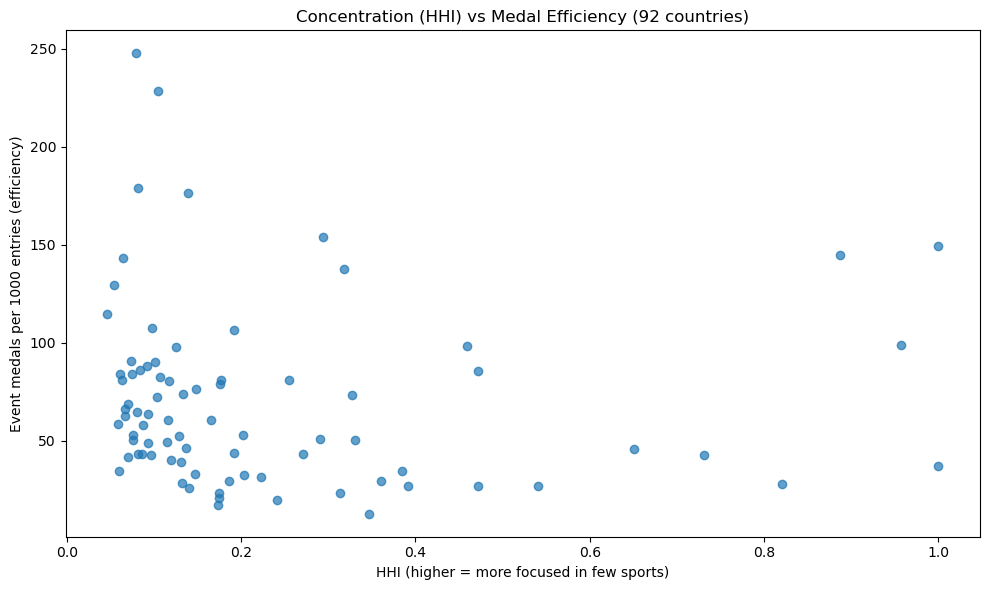

In [121]:
plt.figure(figsize=(10,6))
plt.scatter(stable_92["HHI"], stable_92["eff_event_per_1000"], alpha=0.7)
plt.title("Concentration (HHI) vs Medal Efficiency (92 countries)")
plt.xlabel("HHI (higher = more focused in few sports)")
plt.ylabel("Event medals per 1000 entries (efficiency)")
plt.tight_layout()
plt.savefig("figures/RQ3_plot2_scatter_HHI_vs_efficiency.png", dpi=300)
plt.show()


## RQ3 Plot 3 (All 92): Efficiency distribution (histogram)

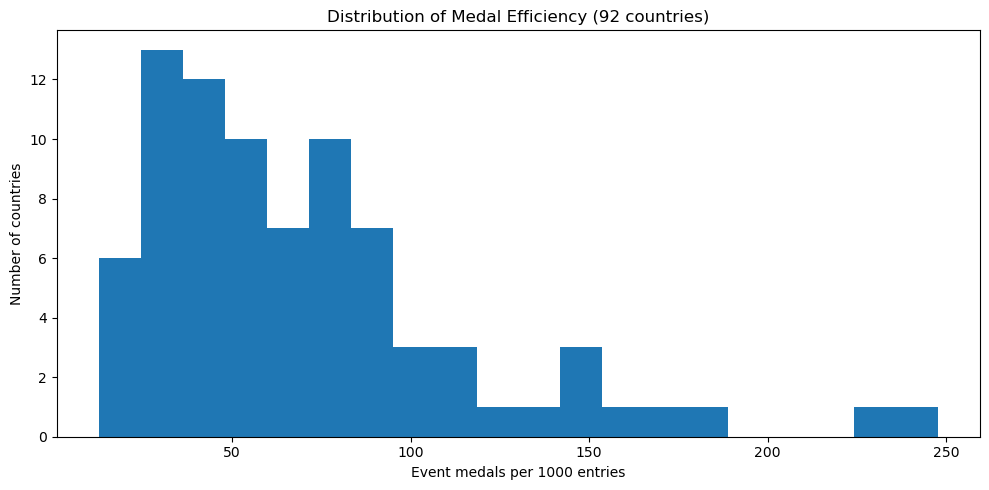

In [122]:
plt.figure(figsize=(10,5))
plt.hist(stable_92["eff_event_per_1000"], bins=20)
plt.title("Distribution of Medal Efficiency (92 countries)")
plt.xlabel("Event medals per 1000 entries")
plt.ylabel("Number of countries")
plt.tight_layout()
plt.savefig("figures/RQ3_plot3_hist_efficiency.png", dpi=300)
plt.show()


## RQ3 Plot 4 (All 92): Efficiency by diversification quartiles (boxplot)

C:\Users\princ\AppData\Local\Temp\ipykernel_33624\1839501060.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=["Low","Mid-Low","Mid-High","High"], showfliers=False)


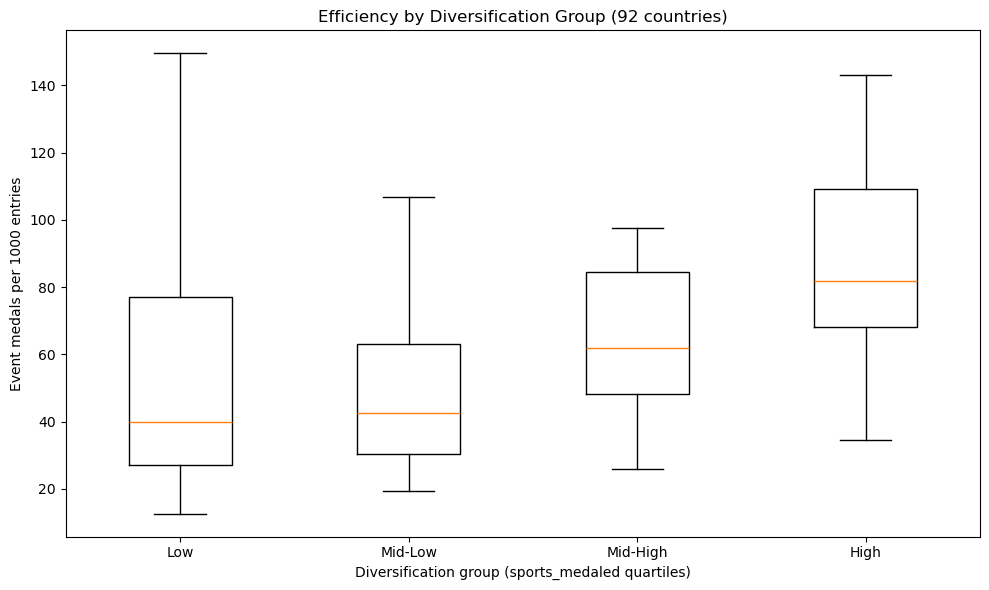

In [123]:
tmp = stable_92.copy()
tmp["div_group"] = pd.qcut(tmp["sports_medaled"], q=4, labels=["Low","Mid-Low","Mid-High","High"])

groups = [tmp[tmp["div_group"]==g]["eff_event_per_1000"].values for g in ["Low","Mid-Low","Mid-High","High"]]

plt.figure(figsize=(10,6))
plt.boxplot(groups, labels=["Low","Mid-Low","Mid-High","High"], showfliers=False)
plt.title("Efficiency by Diversification Group (92 countries)")
plt.xlabel("Diversification group (sports_medaled quartiles)")
plt.ylabel("Event medals per 1000 entries")
plt.tight_layout()
plt.savefig("figures/RQ3_plot4_box_eff_by_div_group.png", dpi=300)
plt.show()


### RQ3-7: Top 20 / Mid 20 / Bottom 20 (based on efficiency)

In [124]:
sorted_eff = stable_92.sort_values("eff_event_per_1000", ascending=False).copy()

top20 = sorted_eff.head(20)
bottom20 = sorted_eff.tail(20)
mid20 = sorted_eff.iloc[len(sorted_eff)//2 - 10 : len(sorted_eff)//2 + 10]

print("Top20 efficiency range:", top20["eff_event_per_1000"].min(), "to", top20["eff_event_per_1000"].max())
print("Mid20 efficiency range:", mid20["eff_event_per_1000"].min(), "to", mid20["eff_event_per_1000"].max())
print("Bottom20 efficiency range:", bottom20["eff_event_per_1000"].min(), "to", bottom20["eff_event_per_1000"].max())


Top20 efficiency range: 85.88957055214725 to 247.72162386081192
Mid20 efficiency range: 48.82924043403769 to 73.70644139387541
Bottom20 efficiency range: 12.671594508975714 to 37.234042553191486


## RQ3 Plot 5: Top 20 most efficient countries (bar chart)

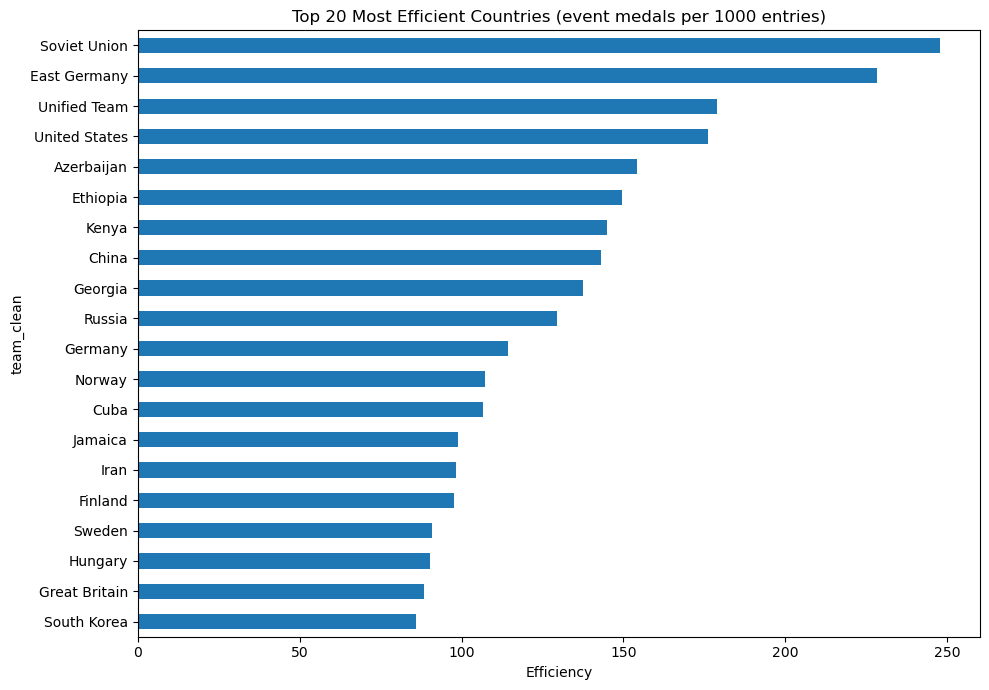

In [125]:
plt.figure(figsize=(10,7))
top20.sort_values("eff_event_per_1000")["eff_event_per_1000"].plot(kind="barh")
plt.title("Top 20 Most Efficient Countries (event medals per 1000 entries)")
plt.xlabel("Efficiency")
plt.tight_layout()
plt.savefig("figures/RQ3_plot5_top20_efficiency.png", dpi=300)
plt.show()


## RQ3 Plot 6: Bottom 20 least efficient countries (bar chart)

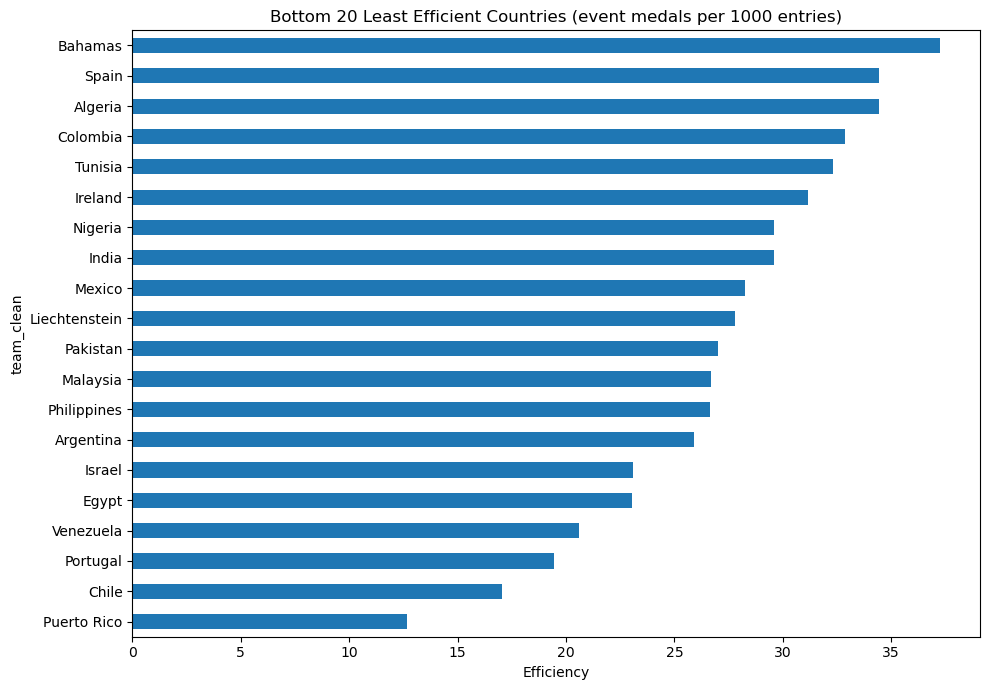

In [126]:
plt.figure(figsize=(10,7))
bottom20.sort_values("eff_event_per_1000")["eff_event_per_1000"].plot(kind="barh")
plt.title("Bottom 20 Least Efficient Countries (event medals per 1000 entries)")
plt.xlabel("Efficiency")
plt.tight_layout()
plt.savefig("figures/RQ3_plot6_bottom20_efficiency.png", dpi=300)
plt.show()


## RQ3 Plot 7: Compare diversification (Top vs Mid vs Bottom efficiency)

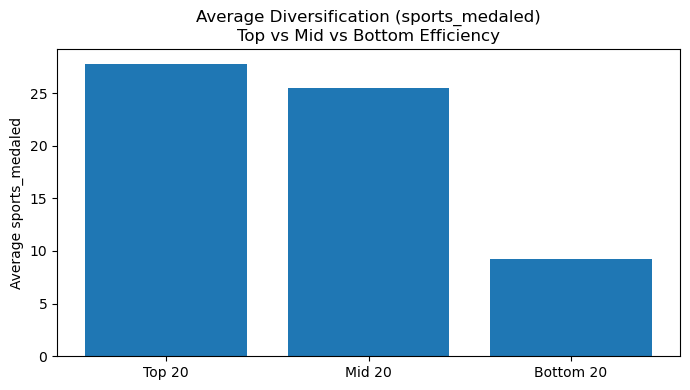

,Average sports_medaled
Top 20,27.80
Mid 20,25.45
Bottom 20,9.25


In [127]:
comp = pd.DataFrame({
    "Top 20": [top20["sports_medaled"].mean()],
    "Mid 20": [mid20["sports_medaled"].mean()],
    "Bottom 20": [bottom20["sports_medaled"].mean()]
}).T
comp.columns = ["Average sports_medaled"]

plt.figure(figsize=(7,4))
plt.bar(comp.index, comp["Average sports_medaled"].values)
plt.title("Average Diversification (sports_medaled)\nTop vs Mid vs Bottom Efficiency")
plt.ylabel("Average sports_medaled")
plt.tight_layout()
plt.savefig("figures/RQ3_plot7_compare_diversification_groups.png", dpi=300)
plt.show()

comp


### RQ3-8: Event-medal rankings over decades (selected 92 countries)

In [128]:
# Event medals per decade per country
evt_dec = event_medals.groupby(["decade","team_clean"]).size().rename("event_medals").reset_index()

# Keep only selected 92
evt_dec = evt_dec[evt_dec["team_clean"].isin(stable_92.index)].copy()

# Rank by decade (1 = best)
evt_dec["rank_event"] = evt_dec.groupby("decade")["event_medals"].rank(ascending=False, method="dense")

evt_dec.head()


,decade,team_clean,event_medals,rank_event
0,1890,Australia,2,8.0
2,1890,Austria,5,6.0
3,1890,Denmark,6,5.0
5,1890,France,11,3.0
6,1890,Germany,13,2.0


## RQ3 Plot 8: Heatmap of event-medal rank by decade (Top 20 efficient)

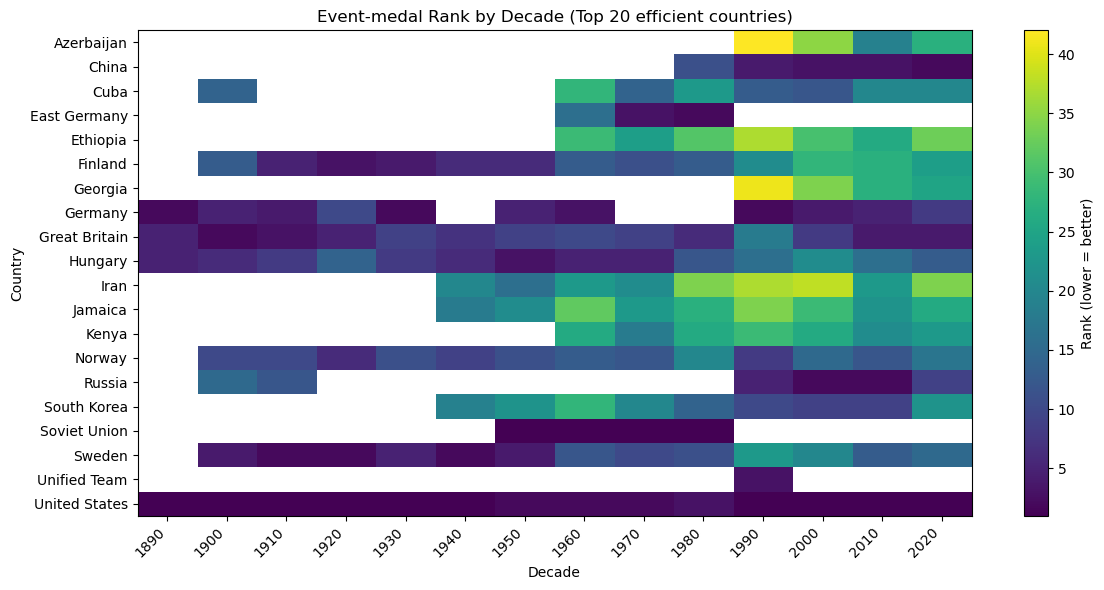

In [129]:
top20_names = top20.index.tolist()

heat_rank = evt_dec[evt_dec["team_clean"].isin(top20_names)].pivot_table(
    index="team_clean", columns="decade", values="rank_event", aggfunc="min"
)

plt.figure(figsize=(12,6))
plt.imshow(heat_rank.values, aspect="auto", interpolation="nearest")
plt.title("Event-medal Rank by Decade (Top 20 efficient countries)")
plt.xlabel("Decade")
plt.ylabel("Country")
plt.xticks(range(len(heat_rank.columns)), heat_rank.columns, rotation=45, ha="right")
plt.yticks(range(len(heat_rank.index)), heat_rank.index)
plt.colorbar(label="Rank (lower = better)")
plt.tight_layout()
plt.savefig("figures/RQ3_plot8_heatmap_rank_by_decade_top20.png", dpi=300)
plt.show()


## RQ3 Plot 9: Stability vs concentration (scatter)
Stability measured as CV = std/mean of event medals across decades.

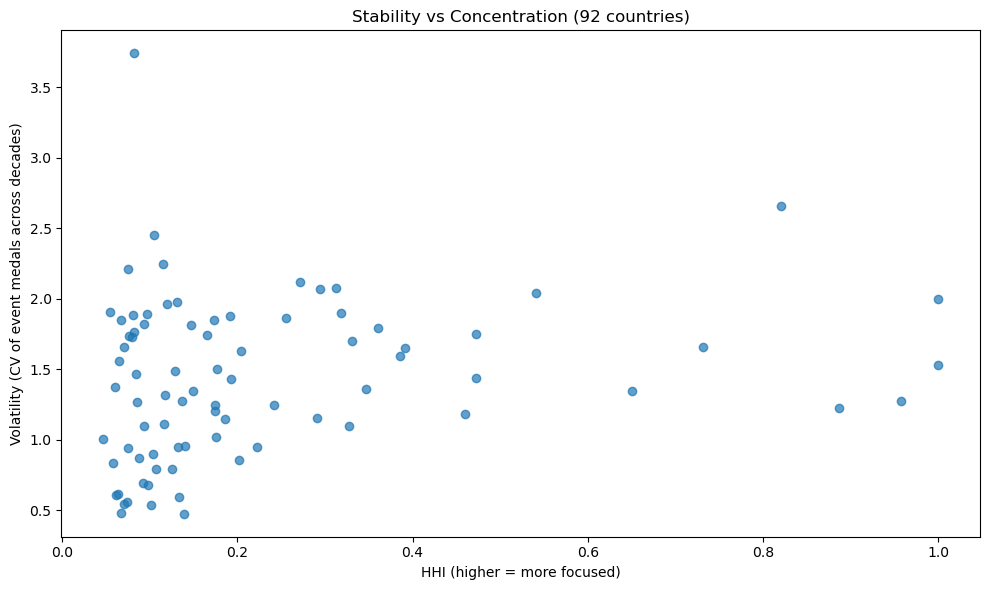

In [130]:
country_dec = evt_dec.pivot_table(index="team_clean", columns="decade", values="event_medals", aggfunc="sum").fillna(0)

mean_medals = country_dec.mean(axis=1)
std_medals = country_dec.std(axis=1)
cv = (std_medals / mean_medals.replace(0, np.nan)).rename("cv_medals")

stability = stable_92.merge(cv, left_index=True, right_index=True, how="left").fillna({"cv_medals": 0})

plt.figure(figsize=(10,6))
plt.scatter(stability["HHI"], stability["cv_medals"], alpha=0.7)
plt.title("Stability vs Concentration (92 countries)")
plt.xlabel("HHI (higher = more focused)")
plt.ylabel("Volatility (CV of event medals across decades)")
plt.tight_layout()
plt.savefig("figures/RQ3_plot9_scatter_HHI_vs_volatility.png", dpi=300)
plt.show()


### RQ3-9 (Optional): Export tables

In [131]:
stable_92.to_csv("outputs/rq3_country_metrics_92.csv", index=True)
top20.to_csv("outputs/rq3_top20_efficiency.csv", index=True)
mid20.to_csv("outputs/rq3_mid20_efficiency.csv", index=True)
bottom20.to_csv("outputs/rq3_bottom20_efficiency.csv", index=True)
print("Saved RQ3 outputs in outputs/")


Saved RQ3 outputs in outputs/
